In [4]:
from pathlib import Path
import json
import tensorflow as tf

# Tujha project path
PROJECT_DIR = Path(r"D:\LIVESTOCK SKIN DISEASE PROJECT")
DATA_DIR = Path(r"D:\livestock_skin_disease_project\dataset\images")
MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (160, 160)
BATCH_SIZE = 16
SEED = 123

# Train, validation, test folders madhun images load
train_ds = tf.keras.utils.image_dataset_from_directory(
    str(DATA_DIR / "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    str(DATA_DIR / "validation"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    str(DATA_DIR / "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Folder names hech model che labels hotil
class_names = train_ds.class_names
print("Model ya classes shikel:", class_names)

# Tinhi splits madhye class folders same aahet ka check
assert class_names == val_ds.class_names, "Validation class folders train peksha vegle aahet"
assert class_names == test_ds.class_names, "Test class folders train peksha vegle aahet"

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# Pretrained MobileNetV2 base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

# Tujhya class count nusar output layer tayar hoil
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.layers.Rescaling(1.0 / 127.5, offset=-1)(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Best model save hoil; val_loss improve nasel tar early stop hoil
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / "livestock_disease_model.keras"),
        monitor="val_loss",
        save_best_only=True
    )
]

# Training suru
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

# Test images var final evaluation
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Model sobat class names pan save kar
with open(MODEL_DIR / "class_names.json", "w") as f:
    json.dump(class_names, f)

print("Training complete!")
print("Model save zala:", MODEL_DIR / "livestock_disease_model.keras")

Found 7233 files belonging to 6 classes.
Found 1073 files belonging to 6 classes.
Found 522 files belonging to 6 classes.
Model ya classes shikel: ['foot_mouth_disease', 'healthy', 'ibk_disease', 'lumpy_skin_disease', 'mastitis', 'ringworm']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/15


d:\livestock_skin_disease_project\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


453/453 ━━━━━━━━━━━━━━━━━━━━ 58s 123ms/step - accuracy: 0.8698 - loss: 0.4139 - val_accuracy: 0.9711 - val_loss: 0.1027
Epoch 2/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 54s 119ms/step - accuracy: 0.9515 - loss: 0.1620 - val_accuracy: 0.9786 - val_loss: 0.0767
Epoch 3/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 55s 122ms/step - accuracy: 0.9570 - loss: 0.1291 - val_accuracy: 0.9832 - val_loss: 0.0657
Epoch 4/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 59s 131ms/step - accuracy: 0.9675 - loss: 0.0983 - val_accuracy: 0.9879 - val_loss: 0.0566
Epoch 5/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 60s 133ms/step - accuracy: 0.9735 - loss: 0.0872 - val_accuracy: 0.9860 - val_loss: 0.0491
Epoch 6/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 59s 131ms/step - accuracy: 0.9739 - loss: 0.0800 - val_accuracy: 0.9851 - val_loss: 0.0538
Epoch 7/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 58s 127ms/step - accuracy: 0.9773 - loss: 0.0689 - val_accuracy: 0.9879 - val_loss: 0.0402
Epoch 8/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 57s 126ms/step - accuracy: 0.9787 - loss: 0.0603 - val

In [8]:
MODEL_DIR = Path(r"D:\livestock_skin_disease_project\models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model.save(str(MODEL_DIR / "livestock_disease_model.keras"))

with open(MODEL_DIR / "class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model ani class names save zale.")

Model ani class names save zale.


In [1]:
import json
import tensorflow as tf
from pathlib import Path

PROJECT_DIR = Path(r"D:\livestock_skin_disease_project")
MODEL_DIR = PROJECT_DIR / "models"

model = tf.keras.models.load_model(
    str(MODEL_DIR / "livestock_disease_model.keras")
)

with open(MODEL_DIR / "class_names.json", "r") as f:
    class_names = json.load(f)

print("Model load zala.")
print("Classes:", class_names)

ImportError: DLL load failed while importing _pywrap_utils: An Application Control policy has blocked this file.

Testing image: D:\livestock_skin_disease_project\dataset\images\test\foot_mouth_disease\fmd_test_img (1).jpg


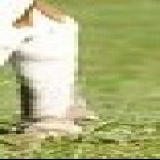

Predicted class: healthy
Confidence: 77.72%


In [10]:
import numpy as np
import tensorflow as tf
from pathlib import Path
from IPython.display import display

TEST_DIR = Path(r"D:\livestock_skin_disease_project\dataset\images\test")

image_files = [
    p for p in TEST_DIR.rglob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

if not image_files:
    raise FileNotFoundError("Test folder madhye JPG kiwa PNG image nahi.")

IMAGE_PATH = image_files[0]
print("Testing image:", IMAGE_PATH)

img = tf.keras.utils.load_img(str(IMAGE_PATH), target_size=(160, 160))
display(img)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)

predictions = model.predict(img_array, verbose=0)[0]
best_index = int(np.argmax(predictions))

print("Predicted class:", class_names[best_index])
print(f"Confidence: {predictions[best_index] * 100:.2f}%")

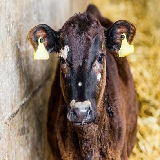

Predicted class: ringworm
Confidence: 65.24%


In [22]:
from pathlib import Path
import numpy as np
import tensorflow as tf
from IPython.display import display

IMAGE_PATH = Path(r"C:\Users\varad\OneDrive\Desktop\images (1).jpg") # ithe tujhya photo cha path

if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Photo sapadla nahi: {IMAGE_PATH}")

img = tf.keras.utils.load_img(str(IMAGE_PATH), target_size=(160, 160))
display(img)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)

predictions = model.predict(img_array, verbose=0)[0]
best_index = int(np.argmax(predictions))

print("Predicted class:", class_names[best_index])
print(f"Confidence: {predictions[best_index] * 100:.2f}%")

In [2]:
from pathlib import Path
import tensorflow as tf

PROJECT_DIR = Path(r"D:\livestock_skin_disease_project")
DATA_DIR = PROJECT_DIR / "dataset" / "images"
MODEL_PATH = PROJECT_DIR / "models" / "livestock_disease_model.keras"

model = tf.keras.models.load_model(str(MODEL_PATH), compile=False)
model.compile(loss="sparse_categorical_crossentropy", metrics=["accuracy"])

test_ds = tf.keras.utils.image_dataset_from_directory(
    str(DATA_DIR / "test"),
    image_size=(160, 160),
    batch_size=16,
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

ImportError: DLL load failed while importing _pywrap_utils: An Application Control policy has blocked this file.